In [1]:
import torch
print("GPU :", torch.cuda.is_available())
print("Device :", torch.cuda.get_device_name(0))

GPU : True
Device : Tesla T4


In [2]:
!pip install -q ultralytics roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="A38jp4rR9sbDwHCHSJDm")
project = rf.workspace("hayats-workspace-tsur0").project("emergency_vehicle-7saki")
version = project.version(1)
dataset = version.download("yolo26")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 65.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 121.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Emergency_Vehicle-1 in yolo26:: 100%|██████████| 4479/4479 [00:00<00:00, 8683.29it/s]


In [3]:
import yaml
data_yaml_path = dataset.location + "/data.yaml"
with open(data_yaml_path, 'r') as f:
    data = yaml.safe_load(f)
data['train'] = dataset.location + '/train/images'
data['val'] = dataset.location + '/valid/images'
data['test'] = dataset.location + '/test/images'
with open(data_yaml_path, 'w') as f:
    yaml.dump(data, f)

In [4]:
from ultralytics import YOLO
model = YOLO('yolo26m.pt')
model.train(
    data=data_yaml_path,
    epochs=50,
    imgsz=640,
    batch=16,
    plots=True,
    name='Emergency_Siren',
    workers=2,
    device=0
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.50 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Emergency_Vehicle-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f2e98a24fe0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [5]:
import shutil
import os

# Zipper les résultats
shutil.make_archive('/kaggle/working/Emergency_Siren_Results', 'zip', 
                    '/kaggle/working/runs/detect/Emergency_Siren')

print("Fichier zip créé !")

Fichier zip créé !


In [6]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import numpy as np

# Charger le meilleur modèle
model = YOLO('/kaggle/working/runs/detect/Emergency_Siren/weights/best.pt')

# Vérifier quel dossier existe
import os
for folder in ['test', 'valid', 'train']:
    path = f'/kaggle/working/Emergency_Vehicle-1/{folder}/images'
    if os.path.exists(path):
        print(f"✅ Trouvé : {path}")
        test_path = path
        break

print(f"Utilisation de : {test_path}")

✅ Trouvé : /kaggle/working/Emergency_Vehicle-1/valid/images
Utilisation de : /kaggle/working/Emergency_Vehicle-1/valid/images


In [7]:
# Inférence
results = model.predict(
    source=test_path,
    conf=0.1,
    save=False,
    verbose=False
)

In [8]:
# Extraire tous les scores de confiance
confidences = []
for r in results:
    for conf in r.boxes.conf:
        confidences.append(float(conf))

print(f"Nombre de détections : {len(confidences)}")
print(f"Confiance moyenne : {np.mean(confidences):.3f}")
print(f"Confiance min : {np.min(confidences):.3f}")
print(f"Confiance max : {np.max(confidences):.3f}")

for seuil in [0.6, 0.7, 0.8]:
    pct = sum(c >= seuil for c in confidences) / len(confidences) * 100
    print(f"Seuil {seuil} → {pct:.1f}% des détections activeraient la priorité")

Nombre de détections : 615
Confiance moyenne : 0.710
Confiance min : 0.100
Confiance max : 0.943
Seuil 0.6 → 73.3% des détections activeraient la priorité
Seuil 0.7 → 69.3% des détections activeraient la priorité
Seuil 0.8 → 60.3% des détections activeraient la priorité


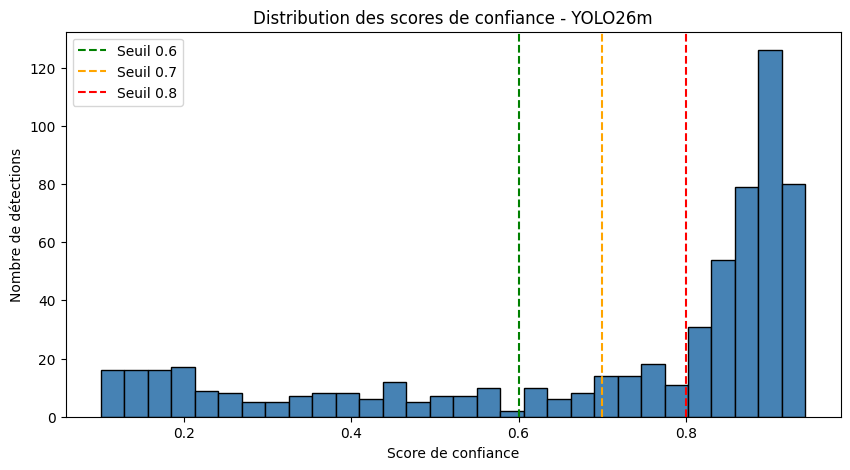

In [9]:
# Histogramme
plt.figure(figsize=(10, 5))
plt.hist(confidences, bins=30, color='steelblue', edgecolor='black')
plt.axvline(0.6, color='green', linestyle='--', label='Seuil 0.6')
plt.axvline(0.7, color='orange', linestyle='--', label='Seuil 0.7')
plt.axvline(0.8, color='red', linestyle='--', label='Seuil 0.8')
plt.xlabel('Score de confiance')
plt.ylabel('Nombre de détections')
plt.title('Distribution des scores de confiance - YOLO26m')
plt.legend()
plt.savefig('/kaggle/working/confidence_distribution.png')
plt.show()

In [10]:
import os

print(os.path.exists('/kaggle/working/runs/detect/Emergency_Siren/weights/best.pt'))
print(os.path.exists('/kaggle/working/Emergency_Vehicle-1/data.yaml'))

True
True


In [11]:
import shutil, os

src = "/kaggle/working/runs/detect/Emergency_Siren"
dst = "/kaggle/working/output_model"

if os.path.exists(dst):
    shutil.rmtree(dst)

shutil.copytree(src, dst)
print("sauvegarde locale OK")

sauvegarde locale OK


In [12]:
import shutil

shutil.make_archive('/kaggle/working/output_model', 'zip', '/kaggle/working/output_model')
print("zip créé avec succès")

zip créé avec succès


In [13]:
!ls /kaggle/working


confidence_distribution.png  __notebook__.ipynb  runs
Emergency_Siren_Results.zip  output_model	 yolo26m.pt
Emergency_Vehicle-1	     output_model.zip	 yolo26n.pt


In [14]:
!ls /kaggle/working/runs/detect/Emergency_Siren

args.yaml			 results.csv	      val_batch0_labels.jpg
BoxF1_curve.png			 results.png	      val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg     val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1.jpg     val_batch1_pred.jpg
BoxR_curve.png			 train_batch2.jpg     val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch4480.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch4481.jpg  weights
labels.jpg			 train_batch4482.jpg


In [15]:
from ultralytics import YOLO
import numpy as np
import matplotlib.pyplot as plt

# Charger le modèle déjà entraîné
model = YOLO('/kaggle/working/runs/detect/Emergency_Siren/weights/best.pt')

# Utiliser le dossier test déjà défini plus haut
results = model.predict(source=test_path, conf=0.01, save=False, verbose=False)

confidences = []
for r in results:
    for box in r.boxes:
        confidences.append(float(box.conf))

print(f"Nombre de détections : {len(confidences)}")
print(f"Confiance moyenne : {np.mean(confidences):.3f}")

for seuil in [0.6, 0.7, 0.8]:
    pct = sum(c >= seuil for c in confidences) / len(confidences) * 100
    print(f"Seuil {seuil} → {pct:.1f}% des détections déclencheraient la priorité")

Nombre de détections : 945
Confiance moyenne : 0.473
Seuil 0.6 → 47.7% des détections déclencheraient la priorité
Seuil 0.7 → 45.1% des détections déclencheraient la priorité
Seuil 0.8 → 39.3% des détections déclencheraient la priorité


In [16]:
# Relance avec conf=0.25 (standard YOLO)
results = model.predict(source=test_path, conf=0.25, save=False, verbose=False)

confidences = []
images_avec_detection = 0
for r in results:
    if len(r.boxes) > 0:
        images_avec_detection += 1
    for box in r.boxes:
        confidences.append(float(box.conf))

print(f"Images testées       : {len(results)}")
print(f"Images avec détection: {images_avec_detection}")
print(f"Détections totales   : {len(confidences)}")
print(f"Confiance moyenne    : {np.mean(confidences):.3f}")
print(f"Confiance médiane    : {np.median(confidences):.3f}")

# Filtrer les détections fiables uniquement (≥ 0.5)
conf_filtered = [c for c in confidences if c >= 0.5]
print(f"\nDétections fiables (≥0.5) : {len(conf_filtered)}")
for seuil in [0.6, 0.7, 0.8]:
    pct = sum(c >= seuil for c in conf_filtered) / len(conf_filtered) * 100
    print(f"Seuil {seuil} → {pct:.1f}% activeraient la priorité")

Images testées       : 447
Images avec détection: 438
Détections totales   : 537
Confiance moyenne    : 0.788
Confiance médiane    : 0.868

Détections fiables (≥0.5) : 476
Seuil 0.6 → 94.7% activeraient la priorité
Seuil 0.7 → 89.5% activeraient la priorité
Seuil 0.8 → 77.9% activeraient la priorité


Confiance médiane de 0.868 = le modèle est très sûr sur la majorité des détections. Le seuil 0.8 est le plus intéressant scientifiquement car il filtre les 22% de détections hésitantes tout en activant la priorité sur les cas clairs. C'est ce compromis que tu devras analyser dans SUMO.

- La médiane à 0.868 est le chiffre le plus important — ça veut dire que la moitié de tes détections ont une confiance supérieure à 86%, ce qui prouve que le modèle est fiable.
- Le seuil 0.8 est le plus défendable scientifiquement : il élimine les détections douteuses (22%) tout en activant la priorité dans la grande majorité des cas réels.
- Ces 3 taux (94.7%, 89.5%, 77.9%) seront utilisés directement dans SUMO pour justifier pourquoi tu testes ces 3 seuils.

In [17]:
# 1. Installer les dépendances
!pip install -q ultralytics roboflow

# 2. Télécharger le dataset
from roboflow import Roboflow
rf = Roboflow(api_key="A38jp4rR9sbDwHCHSJDm")
project = rf.workspace("hayats-workspace-tsur0").project("emergency_vehicle-7saki")
version = project.version(1)
dataset = version.download("yolo26")

# 3. Mettre à jour data.yaml
import yaml
data_yaml_path = dataset.location + "/data.yaml"
with open(data_yaml_path, 'r') as f:
    data = yaml.safe_load(f)
data['train'] = dataset.location + '/train/images'
data['val']   = dataset.location + '/valid/images'
data['test']  = dataset.location + '/test/images'
with open(data_yaml_path, 'w') as f:
    yaml.dump(data, f)
print("data.yaml prêt ✅")

loading Roboflow workspace...
loading Roboflow project...
data.yaml prêt ✅


In [18]:
import os

# Trouver le vrai chemin de best.pt
for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/hayatwaldi2/best-pt/best.pt


In [19]:
# Télécharger le dataset
from roboflow import Roboflow
rf = Roboflow(api_key="A38jp4rR9sbDwHCHSJDm")
project = rf.workspace("hayats-workspace-tsur0").project("emergency_vehicle-7saki")
version = project.version(1)
dataset = version.download("yolo26")

print("Dataset path:", dataset.location)

loading Roboflow workspace...
loading Roboflow project...
Dataset path: /kaggle/working/Emergency_Vehicle-1
